/opt/conda/envs/km310env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import deepdish!
Could not import ray. Parallelized model unavailble.


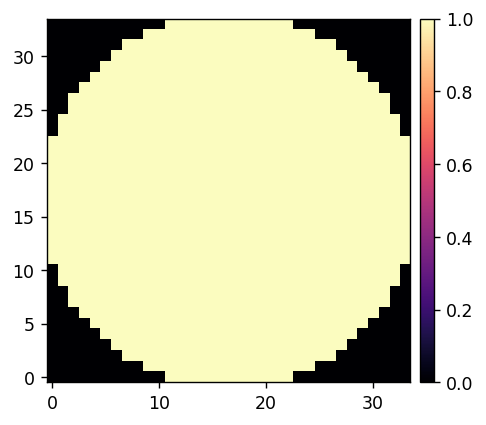

In [1]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import llowfsc
from scoob_llowfsc import wfe

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()
    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

Nact = 34
dm_mask = ensure_np_array(dm.make_mask(Nact))
utils.imshow([dm_mask])

data_path = scoob_llowfsc.path/'exp-data'

In [2]:
dm_wfe_name = 'dm00disp01'

dm_wfe_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_wfe_name}/')

dm_wfe_stream = ImageStream(dm_wfe_name)

# date = 20250409
# date = 20250410
date = today
exp_path = data_path/f'exp-{date}'
wfe_data_path = data_path/f'exp-{today}'/'wfe'
wfe_telem_path = wfe_data_path/'raw-telem'
wfe_unpacked_path = wfe_data_path/'unpacked-telem'

In [3]:
telem.make_dir(exp_path)
telem.make_dir(wfe_data_path)
telem.make_dir(wfe_telem_path)
telem.make_dir(wfe_unpacked_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem' already exists.


# Delete telemetry data if needed to keep data organized.

In [24]:
reload(telem)
telem.delete_files(dm_wfe_rawims_path/'*.xrif')
telem.delete_files(wfe_telem_path/'*')
telem.delete_files(wfe_unpacked_path/f'*')

# Inject WFE with a while loop running at a specific frequency.

In [7]:
reload(scoobi)
scoobi.start_kiloModulator(delay=1)

Session exists for kiloModulator, doing nothing


In [10]:
reload(scoobi)
scoobi.stop_kiloModulator(delay=1)

Waiting for tmux session for kiloModulator to exit...
Waiting for tmux session for kiloModulator to exit...
Waiting for tmux session for kiloModulator to exit...
Waiting for tmux session for kiloModulator to exit...
Waiting for tmux session for kiloModulator to exit...
Waiting for tmux session for kiloModulator to exit...
Killed tmux session for kiloModulator
Ended tmux session for kiloModulator


In [16]:
reload(scoobi)
scoobi.set_kilo_mod_amp(1, client0)
scoobi.set_kilo_mod_rate(500, client0)

In [25]:
reload(telem)
telem.toggle(1, dm_wfe_name, client0, delay=0.5)

In [2]:
reload(scoobi)
scoobi.toggle_kilo_mod(1, client0)

In [3]:
reload(scoobi)
scoobi.toggle_kilo_mod(0, client0)

In [26]:
reload(telem)
telem.toggle(0, dm_wfe_name, client0, delay=0.5)

# Analyze telemetry data.

In [27]:
telem.move_files(dm_wfe_rawims_path, wfe_telem_path)

In [28]:
telem.unpack_data(wfe_telem_path, wfe_unpacked_path)

In [29]:
dm_wfe_fnames = telem.get_fnames(wfe_unpacked_path/f'{dm_wfe_name}*')
dm_wfe_fnames[:5], dm_wfe_fnames[-5:]

(['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250415020415169501116.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250415020415172157803.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250415020415174153980.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250415020415176144337.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250415020415178132289.fits'],
 ['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250415020429661987627.fits',
  '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/wfe/unpacked-telem/dm00disp01_20250415020429663897738.fits',
  '/home/kianmilani

In [30]:
reload(telem)
absolute = 1
dm_wfe_times = telem.read_telem_times(dm_wfe_fnames, absolute=absolute)
dm_wfe_start = dm_wfe_times[0]

Text(0.5, 1.0, 'dm00disp01 Delta Times: FPS = 500.0087864992362')

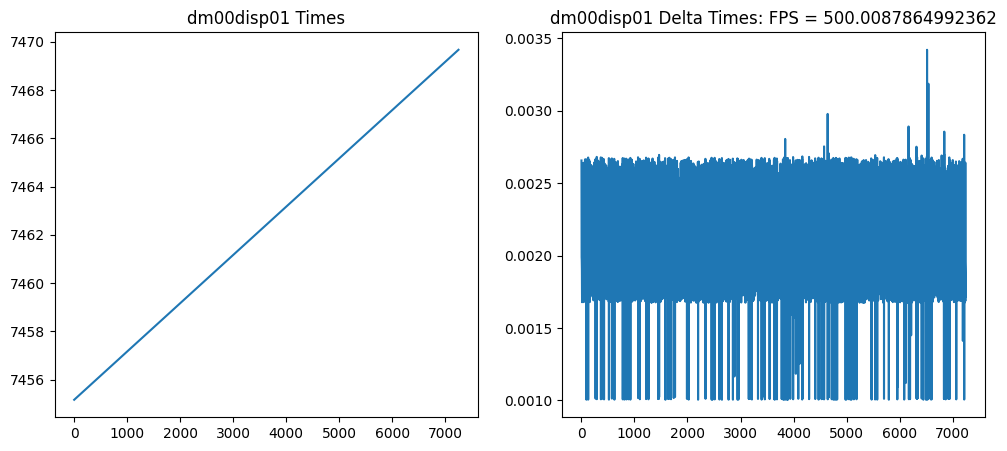

In [31]:
dm_wfe_delTs = dm_wfe_times[1:] - dm_wfe_times[:-1]
mean_fps = 1/np.mean(dm_wfe_delTs)

fig = plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(dm_wfe_times)
plt.title(f'{dm_wfe_name} Times')

plt.subplot(122)
plt.plot(dm_wfe_delTs)
plt.title(f'{dm_wfe_name} Delta Times: FPS = {mean_fps}')

In [14]:
absolute = 1
dm_wfe_data, dm_wfe_times = telem.read_telem_data(dm_wfe_fnames, absolute=absolute)
dm_wfe_start = dm_wfe_times[0]

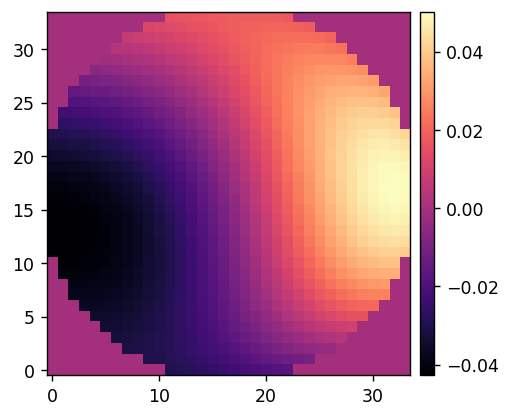

In [17]:
utils.imshow([dm_wfe_data[-2]])